# SSL pretraining demo: one EchoNet-LVH video sample

Walk through one video end to end: raw video → clip sampling → augmentation → dataset output → SimCLR forward pass + loss.

Run with the project `.venv` kernel; the notebook expects to be run from inside `ssl_pretraining/`.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

SSL_DIR = Path.cwd()
if not (SSL_DIR / "dataset.py").exists():
    SSL_DIR = SSL_DIR / "ssl_pretraining"
sys.path.insert(0, str(SSL_DIR))

from dataset import EchoNetLVHDataset
from losses import NT_Xent
from model import SimCLR
from utils import load_video, set_seed

DATA_DIR = SSL_DIR.parent / "data"
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
set_seed(0)
print(f"data_dir={DATA_DIR}  device={DEVICE}  torch={torch.__version__}")


def show_clip(clip, title=""):
    """Plot the frames of a (T, H, W, C) clip side by side."""
    fig, axes = plt.subplots(1, len(clip), figsize=(3 * len(clip), 3))
    for t, ax in enumerate(np.atleast_1d(axes)):
        frame = clip[t]
        ax.imshow(frame if frame.dtype == np.uint8 else np.clip(frame, 0, 1))
        ax.set_title(f"frame {t}")
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

data_dir=/Users/howardbaek/Dropbox/Mac/Documents/echo-severe-as/data  device=mps  torch=2.14.0


## Build the dataset

Finds the `.avi` files under `data/Batch*/` for this split.

In [12]:
dataset = EchoNetLVHDataset(data_dir=str(DATA_DIR), split="train", clip_len=4)
fpath = dataset.fnames[0]
print(fpath)

train: found 10 of 10490 videos (10480 missing on disk)
/Users/howardbaek/Dropbox/Mac/Documents/echo-severe-as/data/Batch1/0X1A026FE97C81DF79.avi


## Raw video

Shape is (frames, height, width, channels), uint8, BGR from OpenCV.

(244, 600, 800, 3) uint8


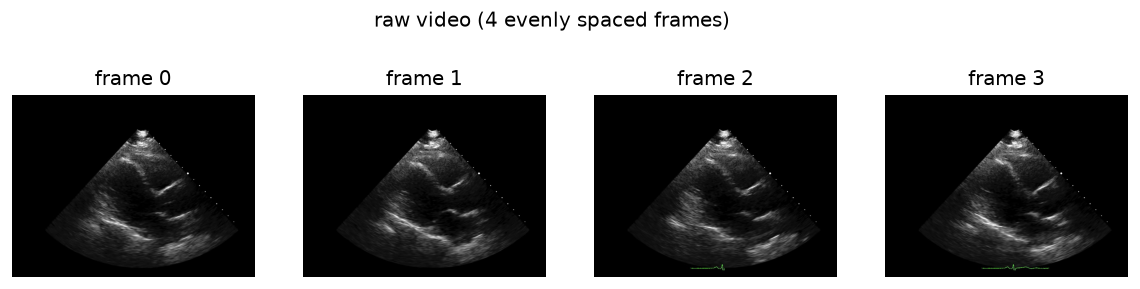

In [13]:
video = load_video(fpath)
print(video.shape, video.dtype)
show_clip(video[:: max(1, len(video) // 4)][:4, ..., ::-1], "raw video (4 evenly spaced frames)")

## Step 1: sample a clip of `clip_len` consecutive frames, then resize

(4, 112, 112, 3)


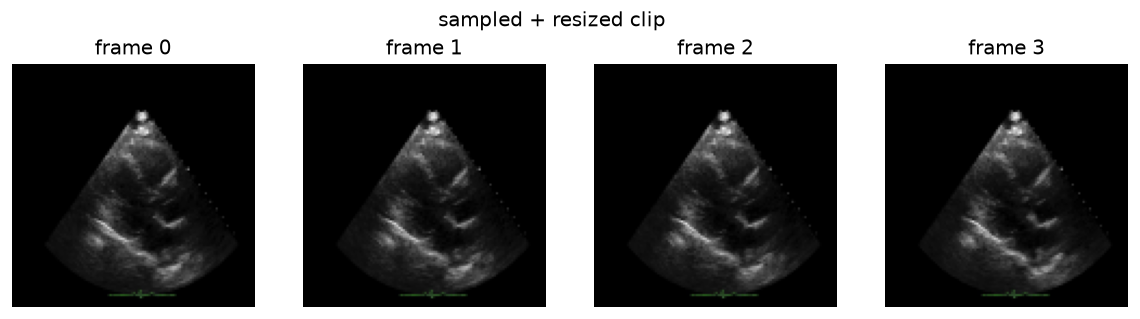

In [14]:
clip = dataset._resize(dataset._sample_frames(video))
print(clip.shape)
show_clip(clip[..., ::-1], "sampled + resized clip")

## Step 2: augment (pad/crop, flip, rotate) and shuffle frames

reordering label: 3 -> permutation (np.int64(0), np.int64(2), np.int64(3), np.int64(1))


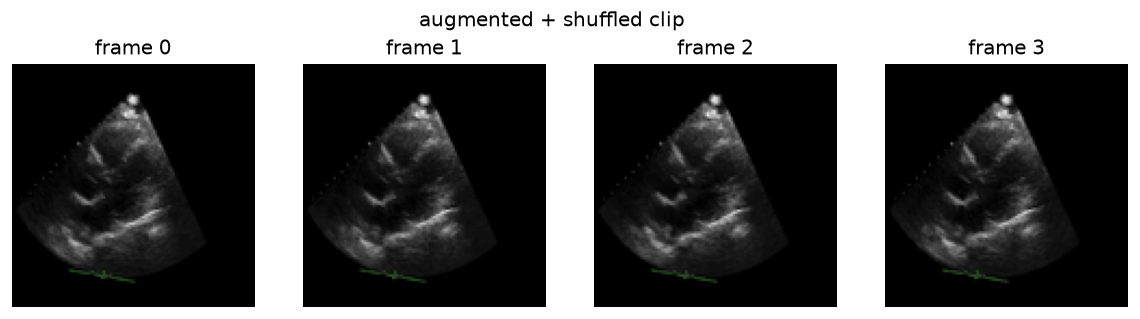

In [15]:
aug_clip, reorder_label = dataset._augment(clip)
print("reordering label:", reorder_label, "-> permutation", dataset.temporal_orderings[reorder_label])
show_clip(aug_clip[..., ::-1], "augmented + shuffled clip")

## Step 3: the full `__getitem__` output

Two views, each (C, T, H, W), plus frame-order labels.

torch.Size([3, 4, 112, 112]) torch.Size([3, 4, 112, 112]) 21 23


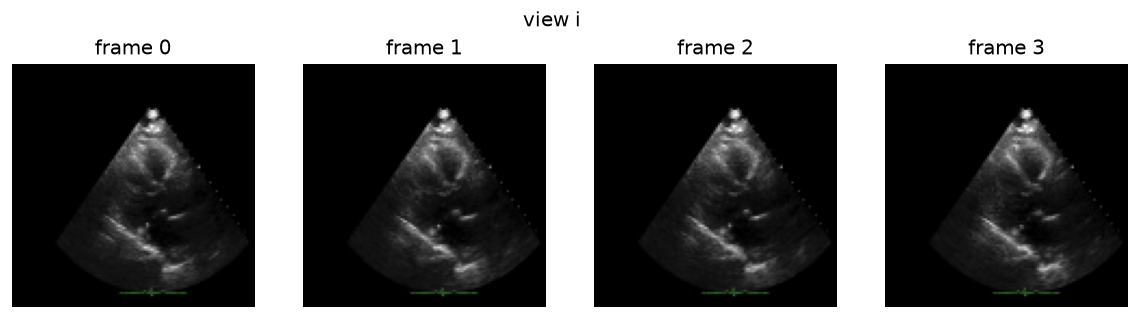

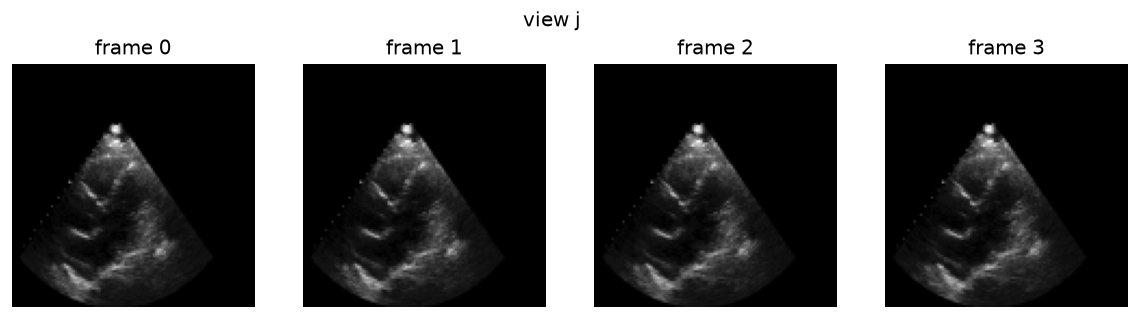

In [16]:
x_i, x_j, t_i, t_j = dataset[0]
print(x_i.shape, x_j.shape, t_i.item(), t_j.item())
show_clip(x_i.permute(1, 2, 3, 0).numpy()[..., ::-1], "view i")
show_clip(x_j.permute(1, 2, 3, 0).numpy()[..., ::-1], "view j")

## Step 4: forward a small batch through SimCLR and compute the pretraining loss

In [17]:
batch_size = 2
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
x_i, x_j, t_i, t_j = [b.to(DEVICE) for b in next(iter(loader))]

encoder = torchvision.models.video.r3d_18(weights=None)
model = SimCLR(encoder=encoder, projection_dim=128, n_features=encoder.fc.in_features).to(DEVICE)

with torch.no_grad():
    h_i, h_j, z_i, z_j, t_hat_i, t_hat_j = model(x_i, x_j)
print("features h:", h_i.shape, " projections z:", z_i.shape, " reorder logits:", t_hat_i.shape)

contrastive = NT_Xent(batch_size, temperature=0.05)(z_i, z_j)
reorder = torch.nn.functional.cross_entropy(torch.cat([t_hat_i, t_hat_j]), torch.cat([t_i, t_j]))
print(f"NT-Xent={contrastive.item():.4f}  reorder CE={reorder.item():.4f}  total={(contrastive + reorder).item():.4f}")

features h: torch.Size([2, 512])  projections z: torch.Size([2, 128])  reorder logits: torch.Size([2, 24])
NT-Xent=1.0621  reorder CE=2.9650  total=4.0271
